In [1]:
import geopandas as gpd
import xarray as xr 
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import sys
sys.path.append('../src')
import importlib
import ntl_functions

importlib.reload(ntl_functions)
from ntl_functions import plot_NASA_NTL, filter_dataset_by_bounding_box, mask_dataset_by_geometry, yearly_radiance, yearly_nonzero_pixels


In [2]:
somaliland_shp_berbera = gpd.read_file(
    "../data/Combined_Datasets/Somaliland_with_berbera/somaliland_with_berbera.shp"
)

SL_berbera = xr.open_dataset("../data/NTL_Data/141225_SL_Berbera_VNP46A4_EY_2012_24.nc")

logged_NTL = xr.where(
    SL_berbera.isnull(), 
    np.nan,
    xr.where(
        SL_berbera > 0,
        np.log(SL_berbera),
        0
    )
)


region_geoms = {
    region: somaliland_shp_berbera.loc[
        somaliland_shp_berbera["admin1Name"] == region
    ]
    for region in somaliland_shp_berbera["admin1Name"].unique()
}
regions = {}
regions_logged = {}

for region, geom in region_geoms.items():
    masked_ntl = mask_dataset_by_geometry(SL_berbera, geom)
    masked_ntl_logged = mask_dataset_by_geometry(logged_NTL, geom)

    regions[region] = filter_dataset_by_bounding_box(masked_ntl, geom)
    regions_logged[region] = filter_dataset_by_bounding_box(masked_ntl_logged, geom)



#Cities
city_shapefiles = {
    "Hargeisa": "../data/Combined_Datasets/Hargeisa_shp/HGA.shp",
    "Berbera": "../data/Combined_Datasets/Berbera_shp/Berbera.shp",
    "Burao": "../data/Combined_Datasets/Burao_shp/Burao.shp",
    "Boroma": "../data/Combined_Datasets/Boroma_shp/Boroma.shp",
    "Erigavo": "../data/Combined_Datasets/Erigavo_shp/Erigavo.shp",
    "Las_Anod": "../data/Combined_Datasets/Las_Anod_shp/Las_Anod.shp",
}

cities = {
    city: gpd.read_file(path)
    for city, path in city_shapefiles.items()
}


cities_ntl = {}
cities_ntl_logged = {}

for city, geom in cities.items():
    cities_ntl[city] = filter_dataset_by_bounding_box(SL_berbera, geom)
    cities_ntl_logged[city] = filter_dataset_by_bounding_box(logged_NTL, geom)


c:\Users\samsa\Documents\NTL_Somaliland\venv\Lib\site-packages\xarray\computation\apply_ufunc.py:818: RuntimeWarning: divide by zero encountered in log
  result_data = func(*input_data)


## Somaliland

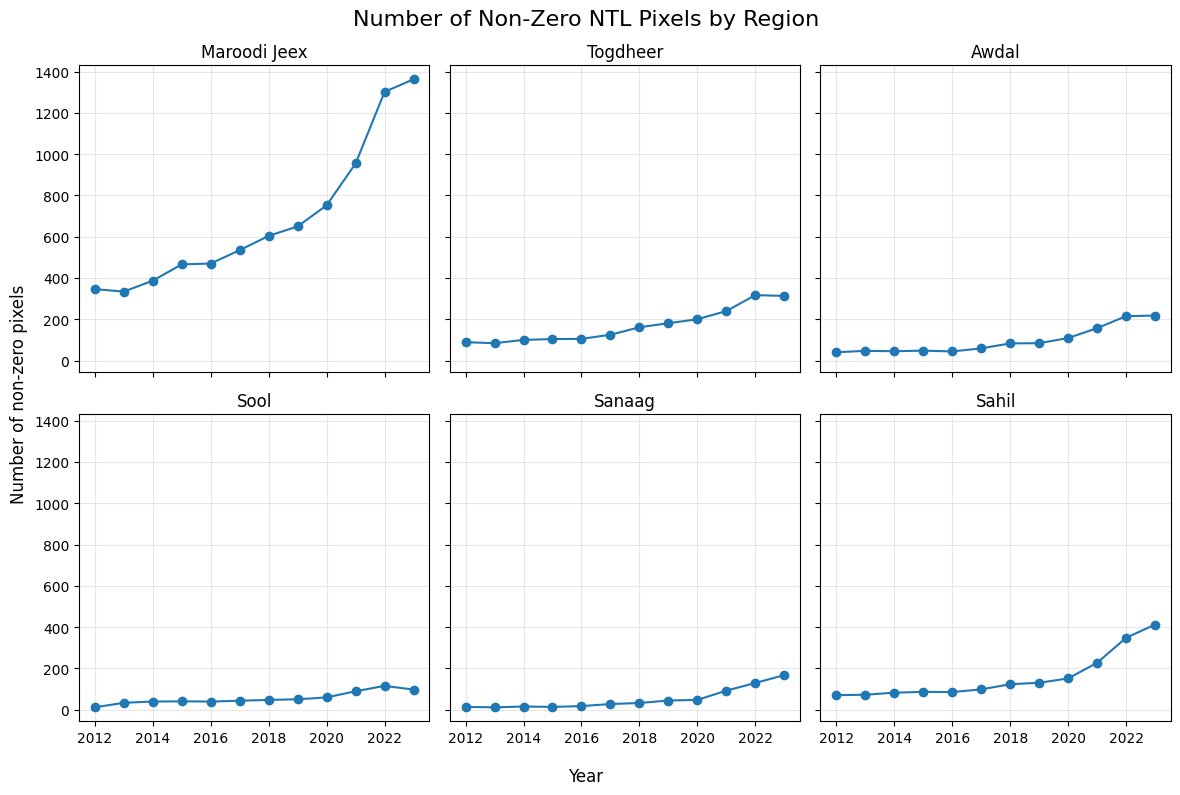

In [25]:

n_regions = len(regions)

# Arrange subplots in 2 columns
n_cols = 3
n_rows = (n_regions + n_cols - 1) // n_cols

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(12, 4 * n_rows),
    sharex=True,
    sharey=True
)

# Flatten axes so we can loop over them easily
axes = axes.flatten()

for ax, (region, ds) in zip(axes, regions.items()):

    ntl = ds["NearNadir_Composite_Snow_Free"]

    # Count non-zero pixels for each year
    non_zero_pixels = (ntl > 0).sum(dim=["x", "y"])

    years = non_zero_pixels.time.to_index()

    ax.plot(
        years,
        non_zero_pixels.values,
        marker="o"
    )

    ax.set_title(region)
    ax.grid(True, alpha=0.3)

# Common axis labels
fig.supxlabel("Year")
fig.supylabel("Number of non-zero pixels")

# Remove any unused subplots
for ax in axes[n_regions:]:
    ax.remove()

fig.suptitle(
    "Total Number of Lit NTL Pixels by Region",
    fontsize=16
)

fig.tight_layout()

fig.savefig(
    "../Report/figures/NTL_NonZero_Pixels_by_Region.png",
    dpi=300,
    bbox_inches="tight"
)
fig.savefig(
    f'../output/Graphics/SL_2012_logged.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()
plt.close(fig)

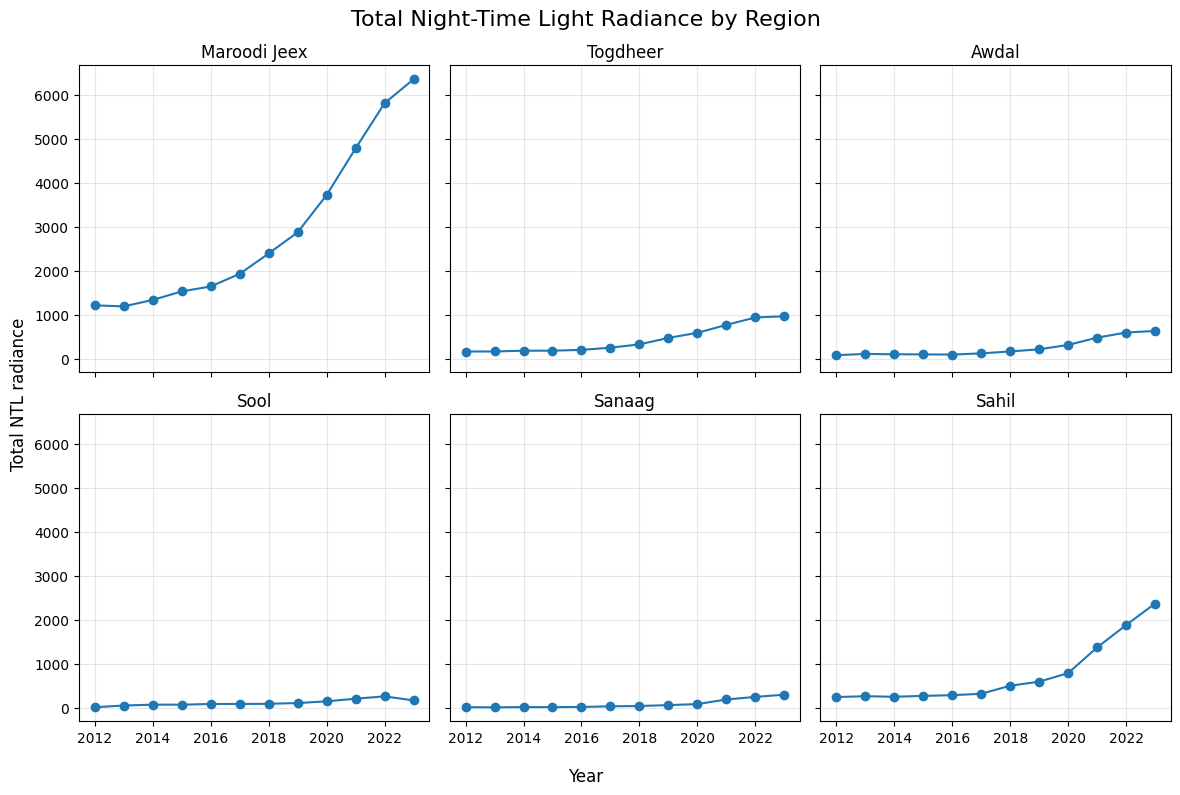

In [27]:
n_cols = 3
n_rows = (n_regions + n_cols - 1) // n_cols

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(12, 4 * n_rows),
    sharex=True,
    sharey=True
)

# Flatten axes so we can loop over them
axes = axes.flatten()

for ax, (region, ds) in zip(axes, regions.items()):

    ntl = ds["NearNadir_Composite_Snow_Free"]

    # Sum NTL radiance across all pixels for each year
    total_radiance = ntl.sum(dim=["x", "y"])

    years = total_radiance.time.to_index()

    ax.plot(
        years,
        total_radiance.values,
        marker="o"
    )

    ax.set_title(region)
    ax.grid(True, alpha=0.3)

# Common axis labels
fig.supxlabel("Year")
fig.supylabel("Total NTL radiance")

# Remove unused subplots
for ax in axes[n_regions:]:
    ax.remove()

fig.suptitle(
    "Total Night-Time Light Radiance by Region",
    fontsize=16
)

fig.tight_layout()

fig.savefig(
    "../Report/figures/NTL_Total_Radiance_by_Region.png",
    dpi=300,
    bbox_inches="tight"
)

fig.savefig(
    f'../output/Graphics/NTL_Total_Radiance_by_Region.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()
plt.close(fig)

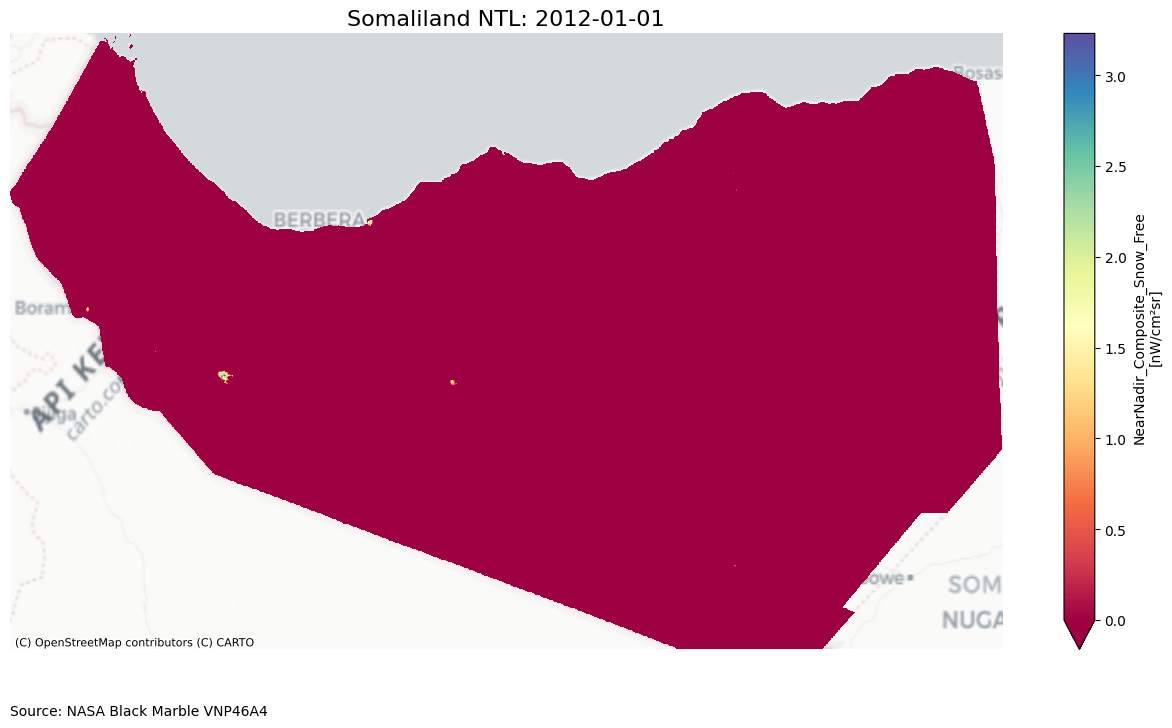

In [28]:
plot_NASA_NTL(logged_NTL, somaliland_shp_berbera, date = "2012-01-01", 
              variable = "NearNadir_Composite_Snow_Free",
              title_prefix = "Somaliland NTL",
              robust = False, vmin=0)
plt.savefig(f'../output/Graphics/SL_2012_logged.png', dpi=300, bbox_inches='tight')  
plt.savefig(f'../Report/figures/SL_2012_logged.png', dpi=300, bbox_inches='tight') 


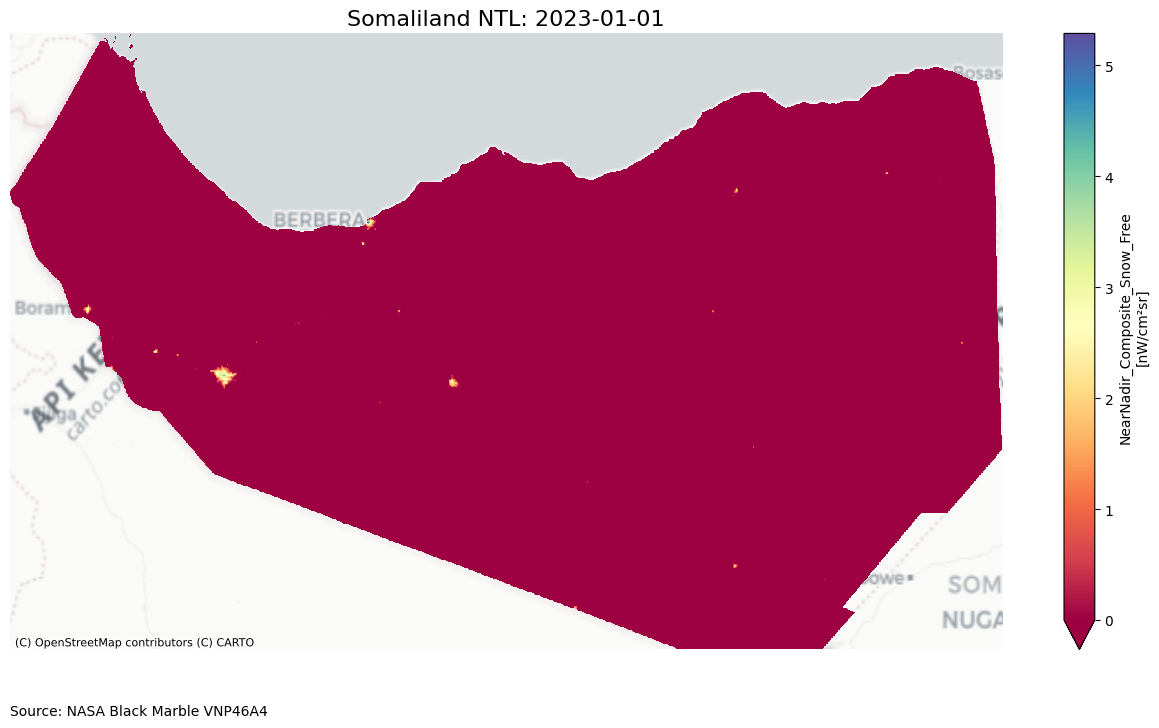

In [29]:
plot_NASA_NTL(logged_NTL, somaliland_shp_berbera, date = "2023-01-01", 
              variable = "NearNadir_Composite_Snow_Free",
              title_prefix = "Somaliland NTL",
              robust = False, vmin=0)
plt.savefig(f'../output/Graphics/SL_2023_logged.png', dpi=300, bbox_inches='tight')  
plt.savefig(f'../Report/figures/SL_2023_logged.png', dpi=300, bbox_inches='tight') 


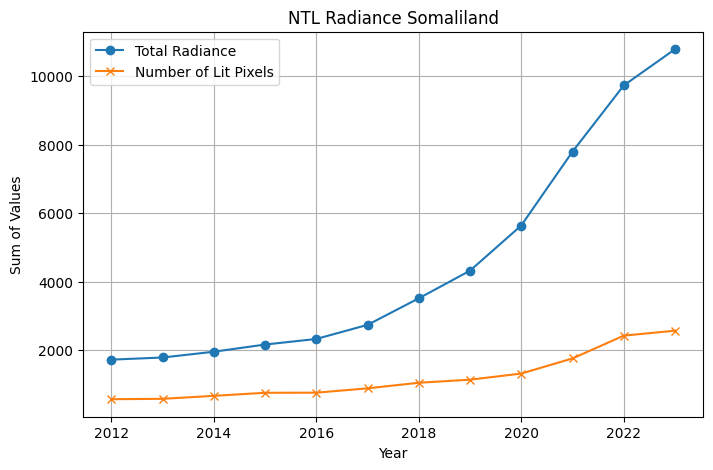

In [7]:
plt.figure(figsize=(8,5))
plt.plot(SL_berbera["NearNadir_Composite_Snow_Free"].sum(dim=["x", "y"]).time.to_index(), SL_berbera["NearNadir_Composite_Snow_Free"].sum(dim=["x", "y"]).values, marker="o")
plt.plot(SL_berbera["NearNadir_Composite_Snow_Free"].sum(dim=["x", "y"]).time.to_index(), (SL_berbera["NearNadir_Composite_Snow_Free"] > 0).sum(dim=["x", "y"]).values, marker="x")
plt.title("NTL Radiance Somaliland")
plt.xlabel("Year")
plt.ylabel("Sum of Values")
plt.legend(["Total Radiance", "Number of Lit Pixels"])
plt.grid(True)
plt.savefig(f'../output/Graphics/SL_Total_Pixels_Rad.png', dpi=300, bbox_inches='tight')  
plt.savefig(f'../Report/figures/SL_Total_Pixels_Rad.png', dpi=300, bbox_inches='tight')  
plt.show()


## Regional

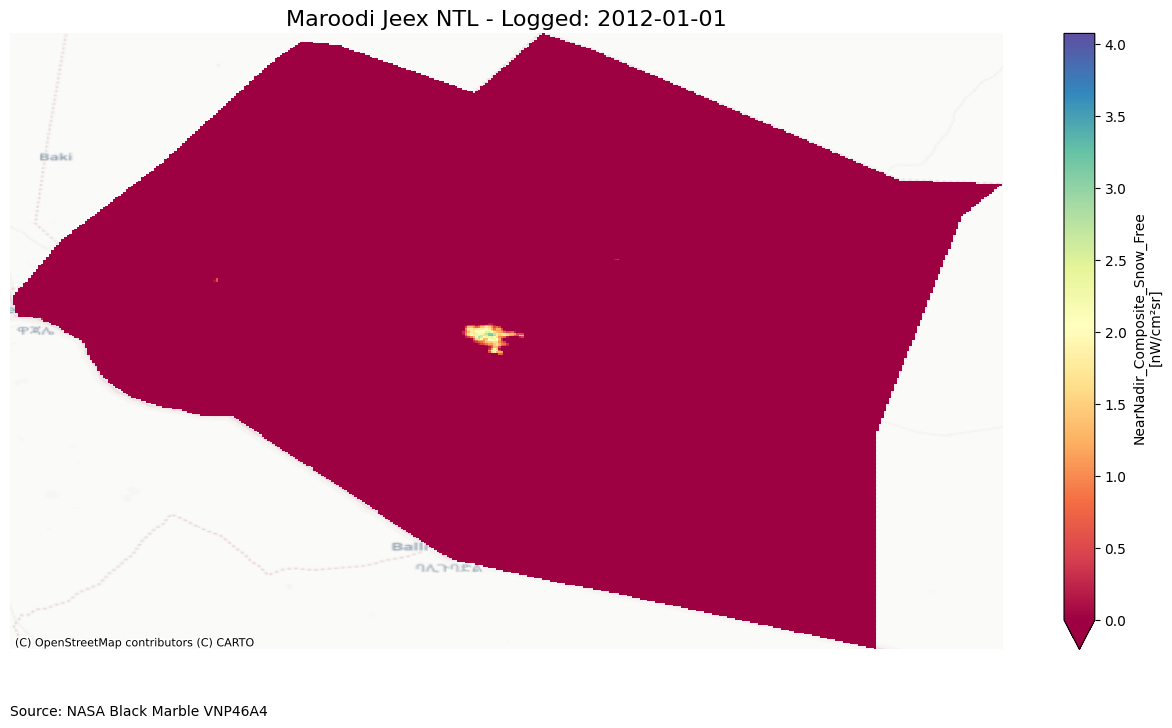

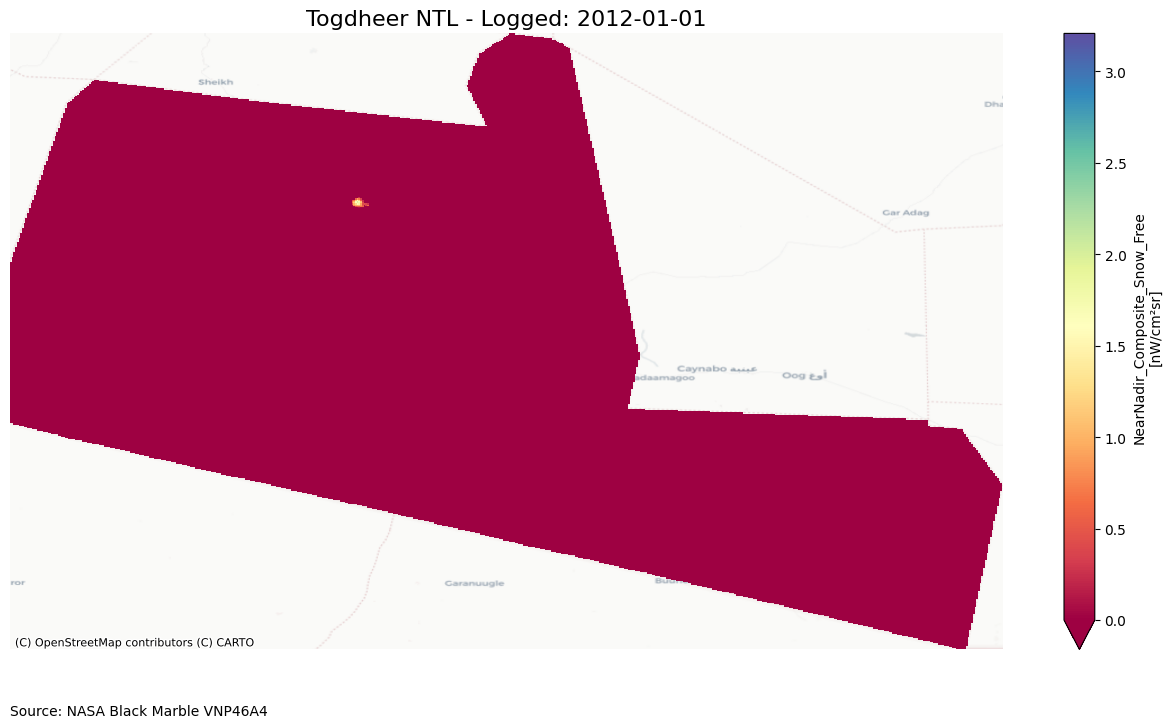

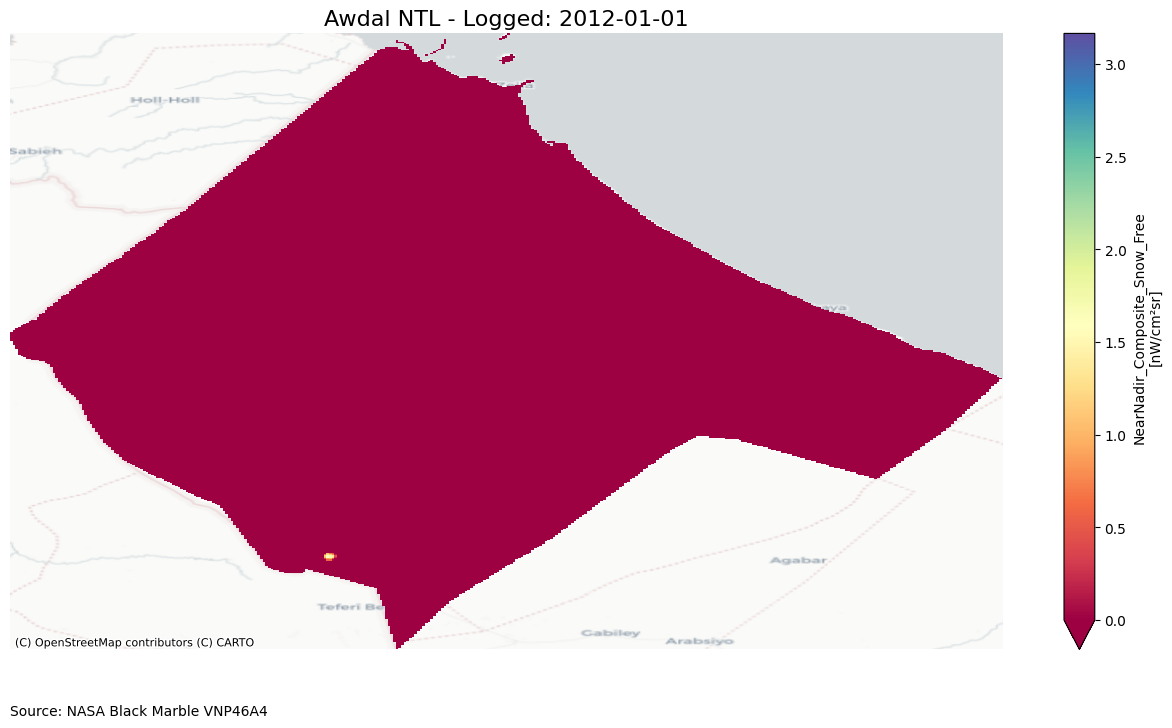

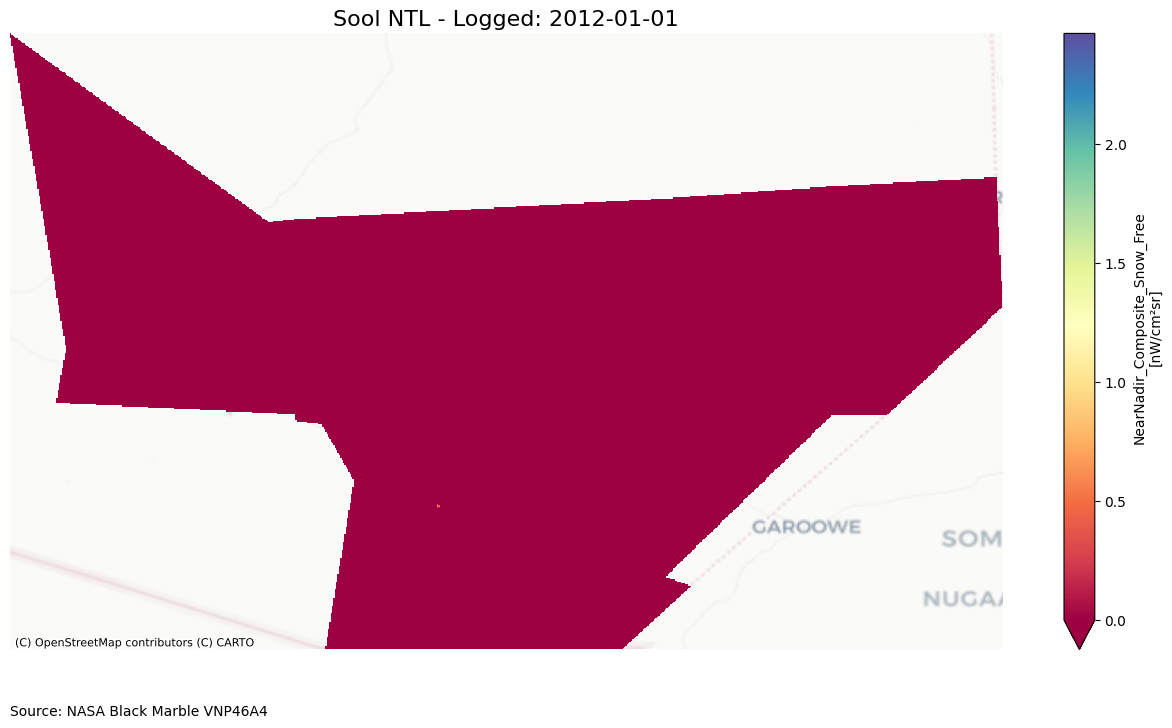

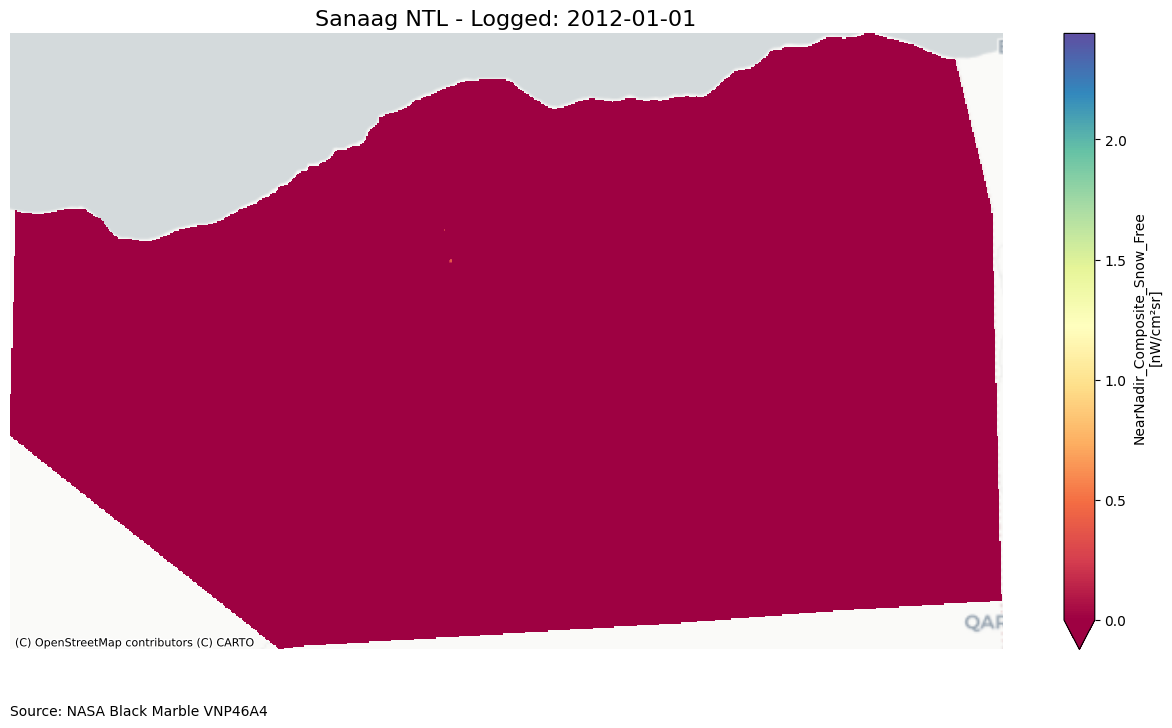

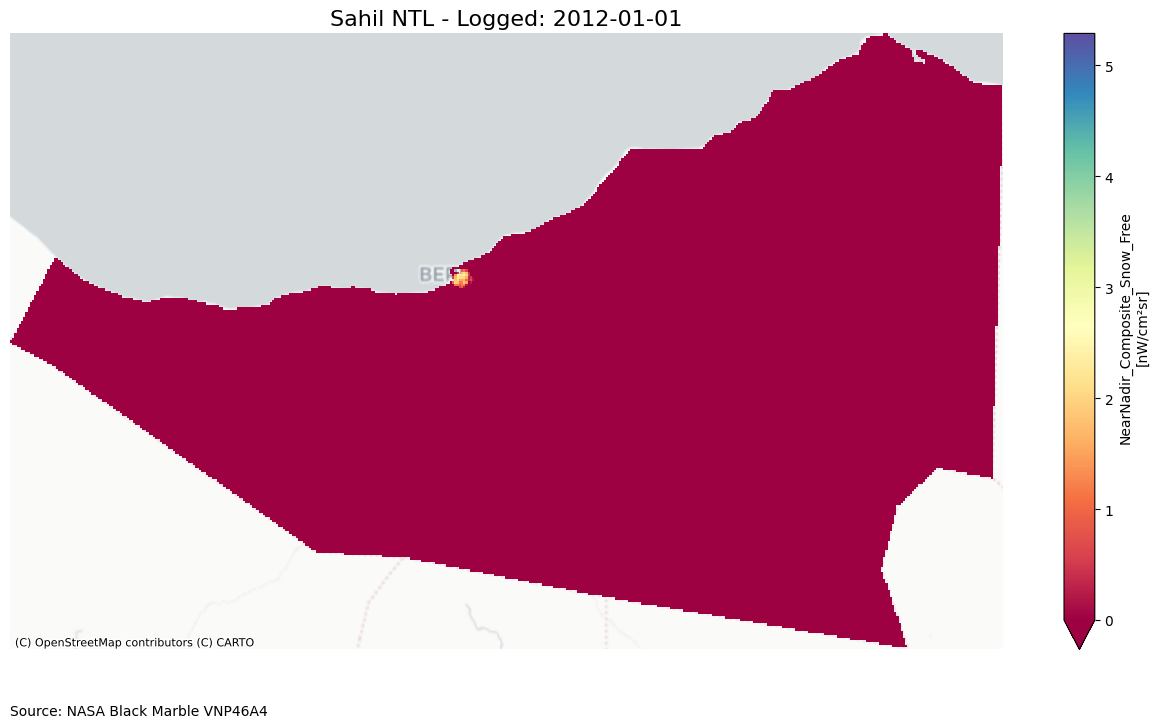

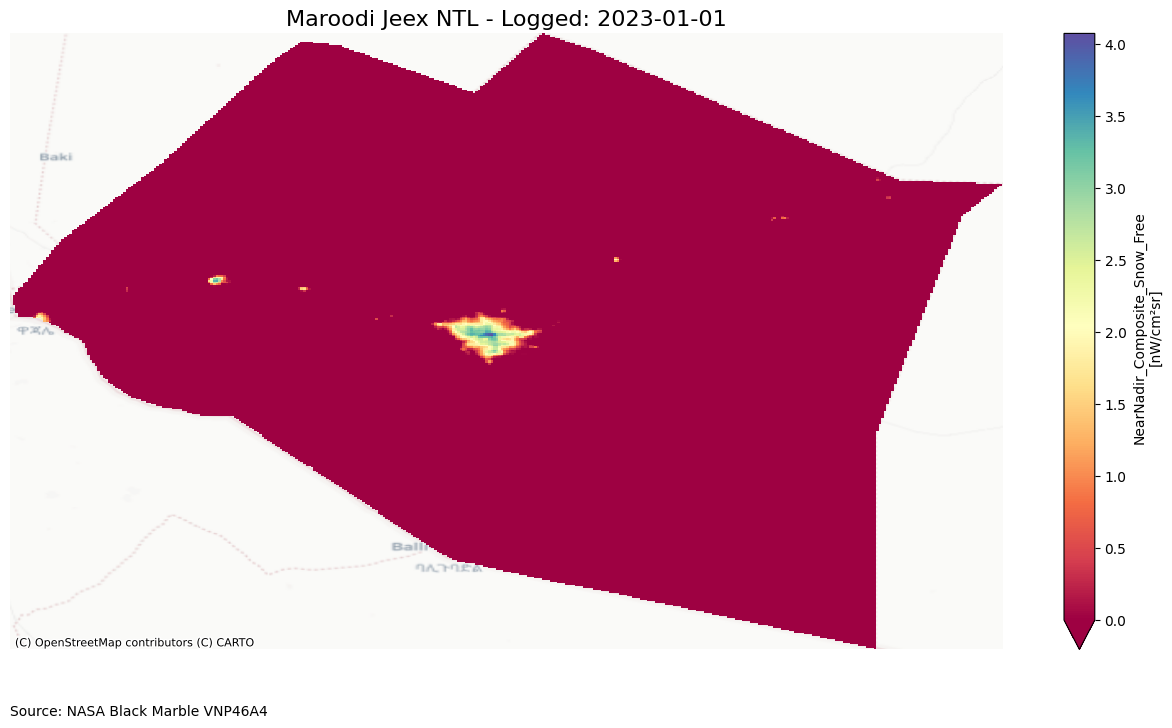

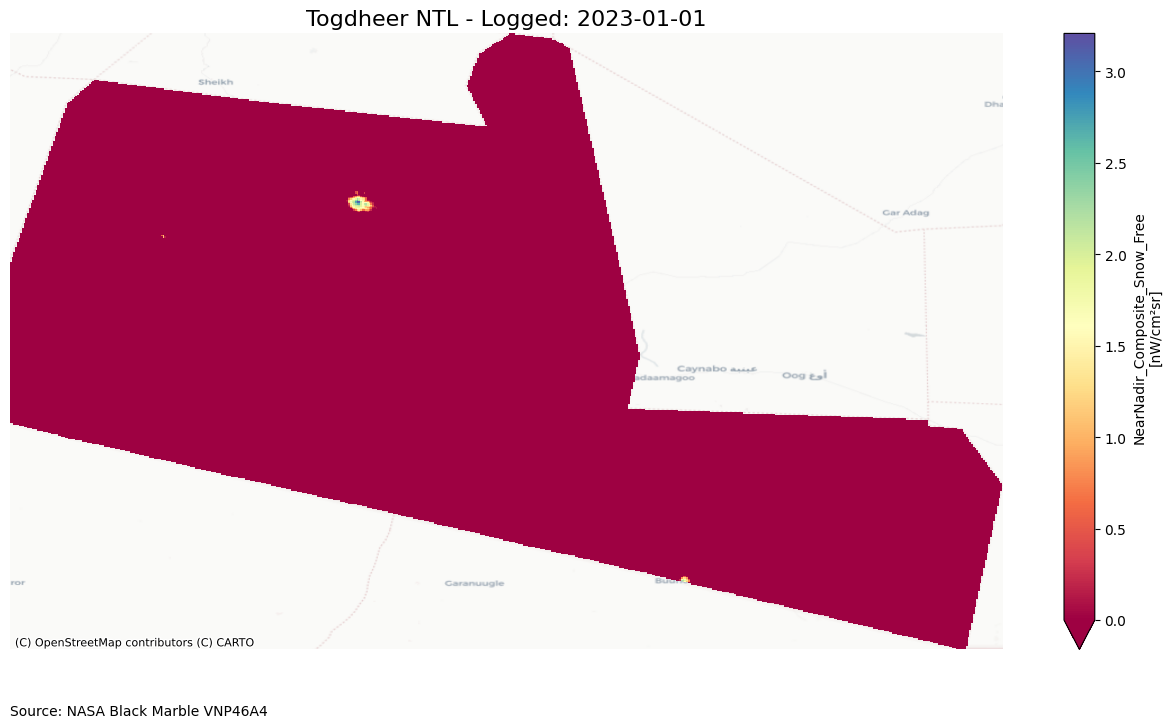

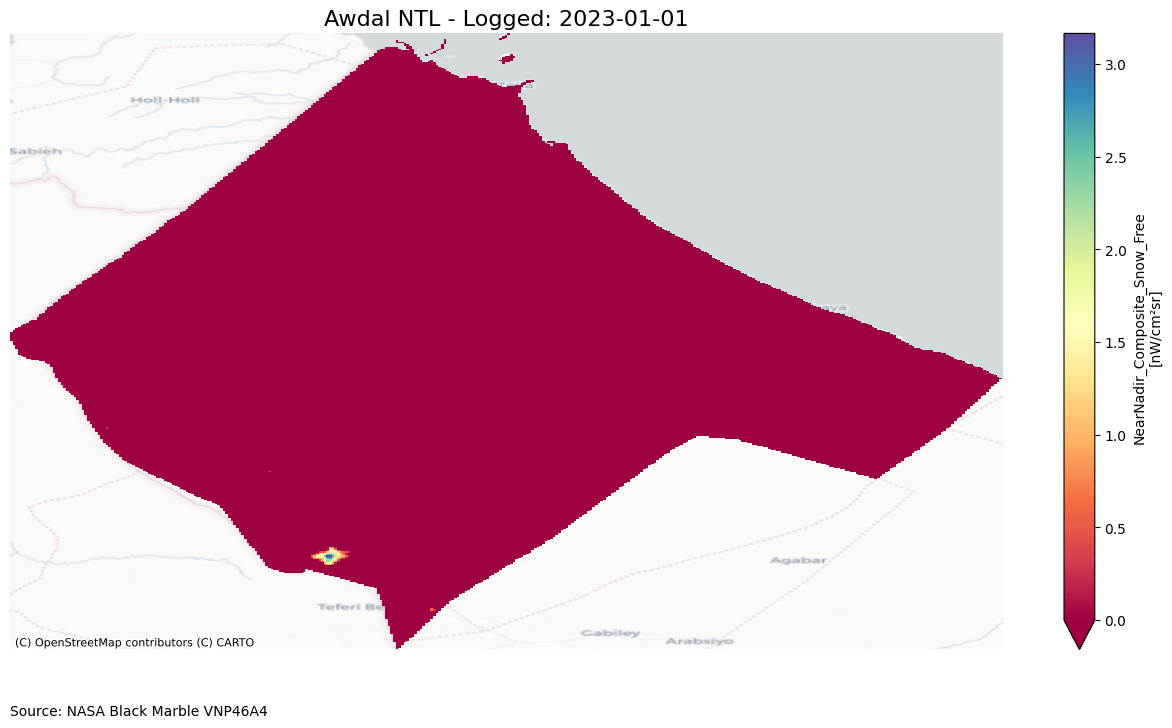

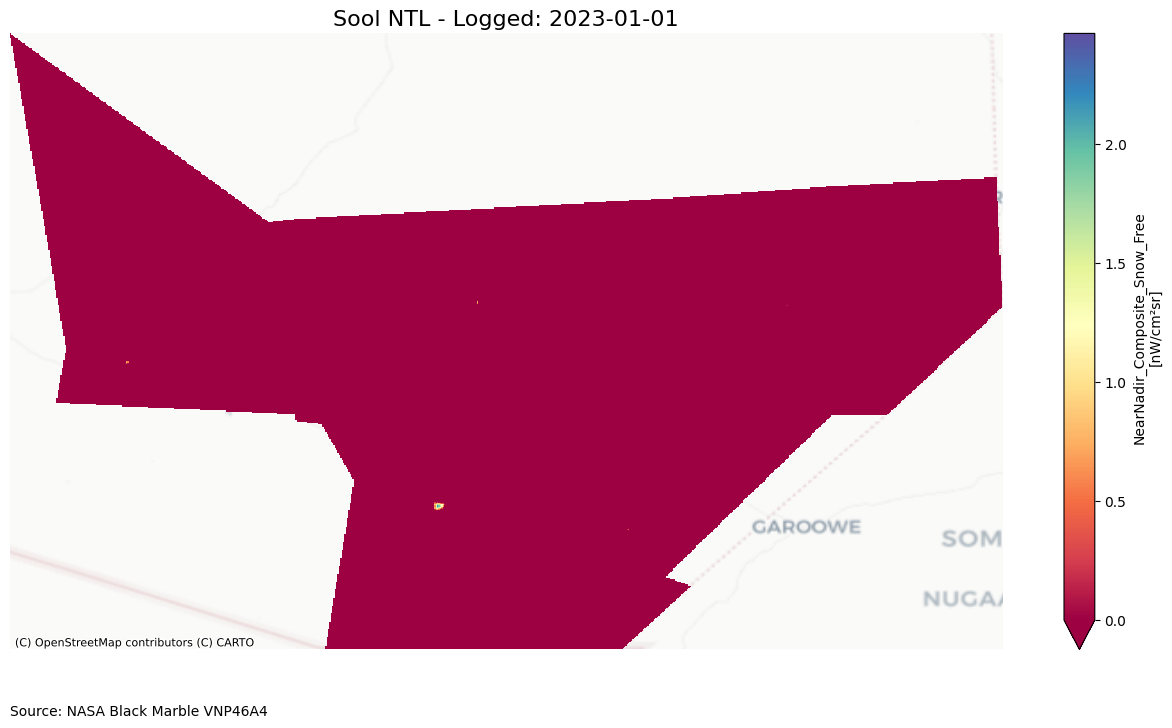

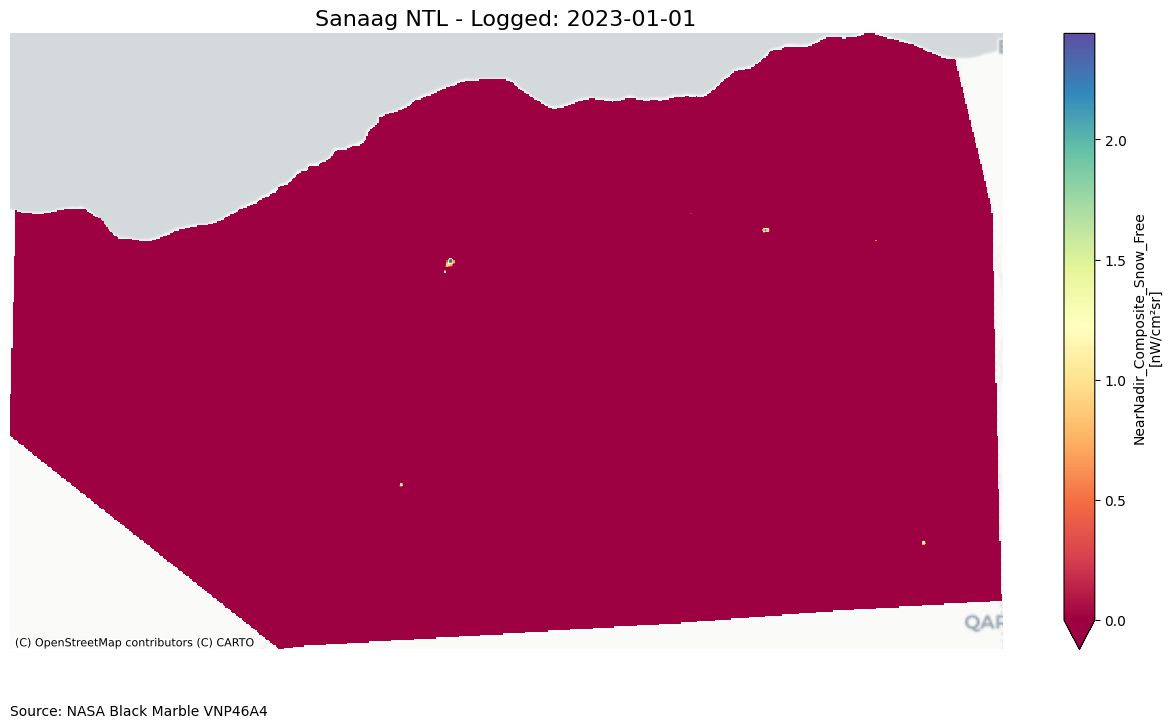

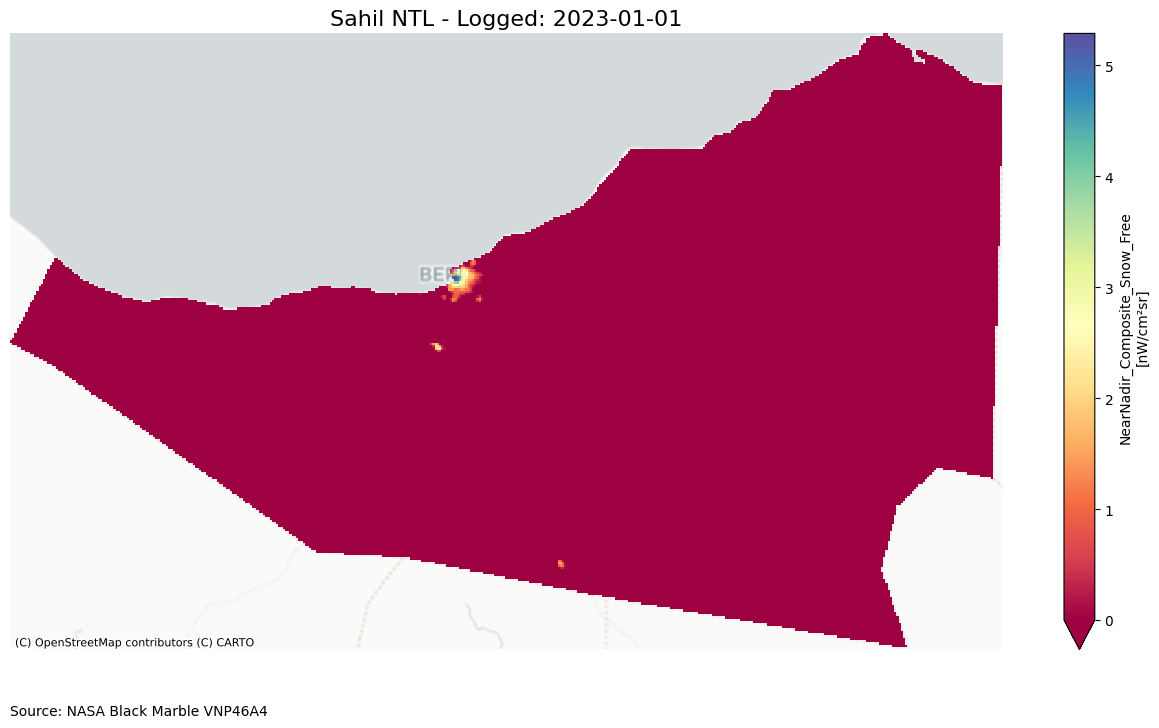

In [34]:
for year in [2012, 2023]:
    for region in regions_logged.keys():
        data = regions_logged[region]
        plot_NASA_NTL(data, somaliland_shp_berbera[somaliland_shp_berbera["admin1Name"]==f"{region}"], date = f"{year}-01-01", 
                      variable = "NearNadir_Composite_Snow_Free",
                      title_prefix = f"{region} NTL - Logged",
                      robust = False, vmin=0, vmax = data["NearNadir_Composite_Snow_Free"].max())
        plt.savefig(f'../output/Graphics/{region}_{year}.png', dpi=300, bbox_inches='tight')

## Urban

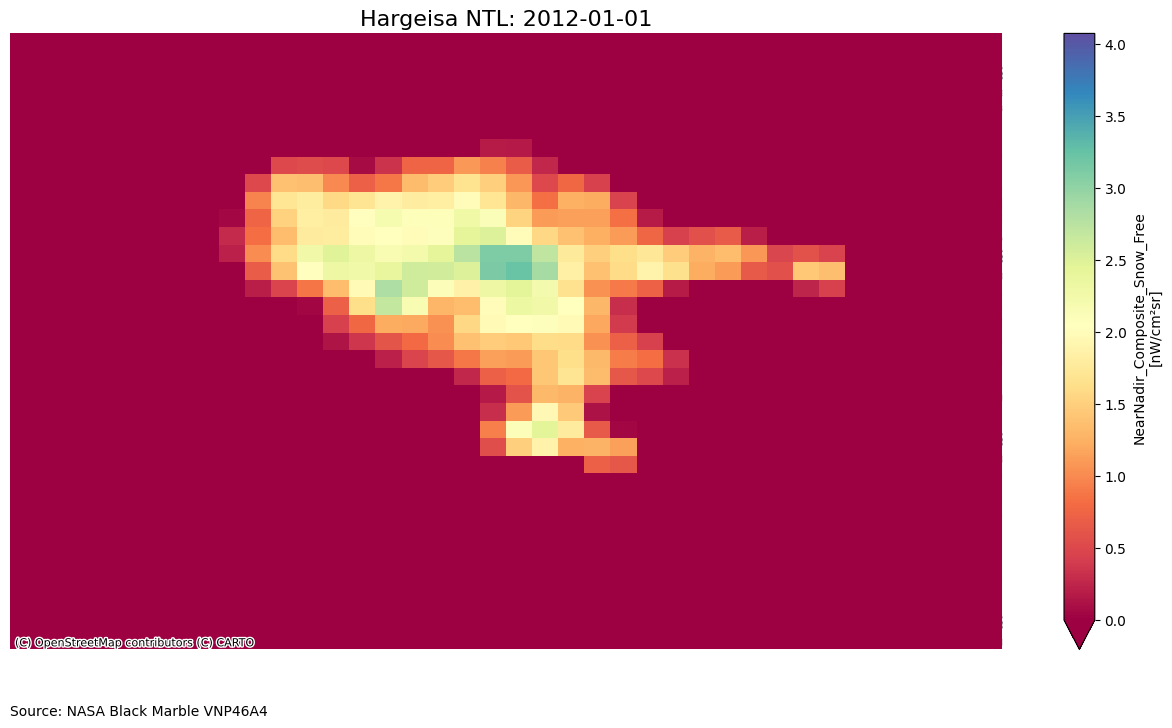

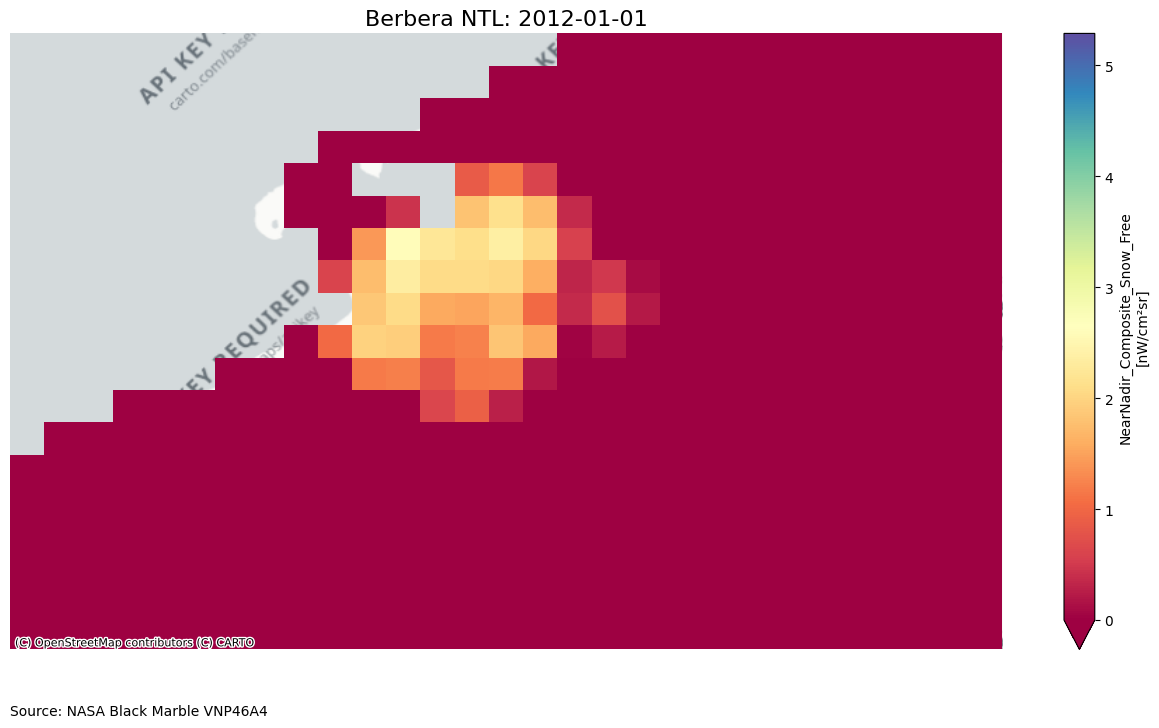

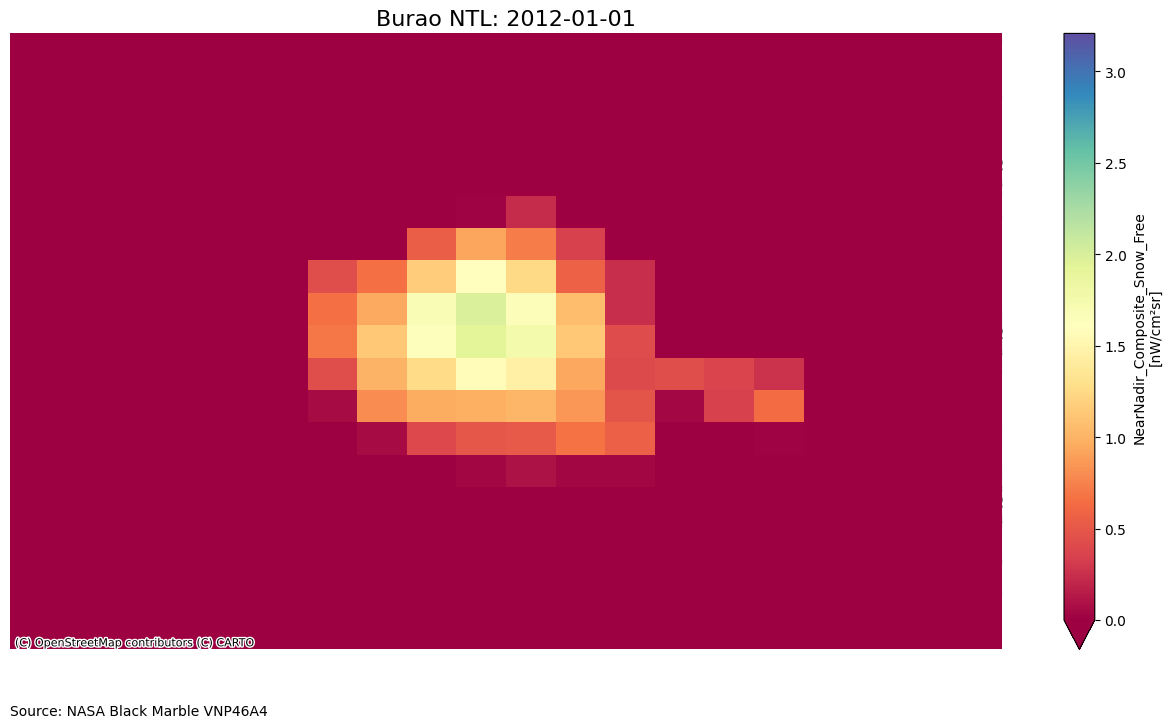

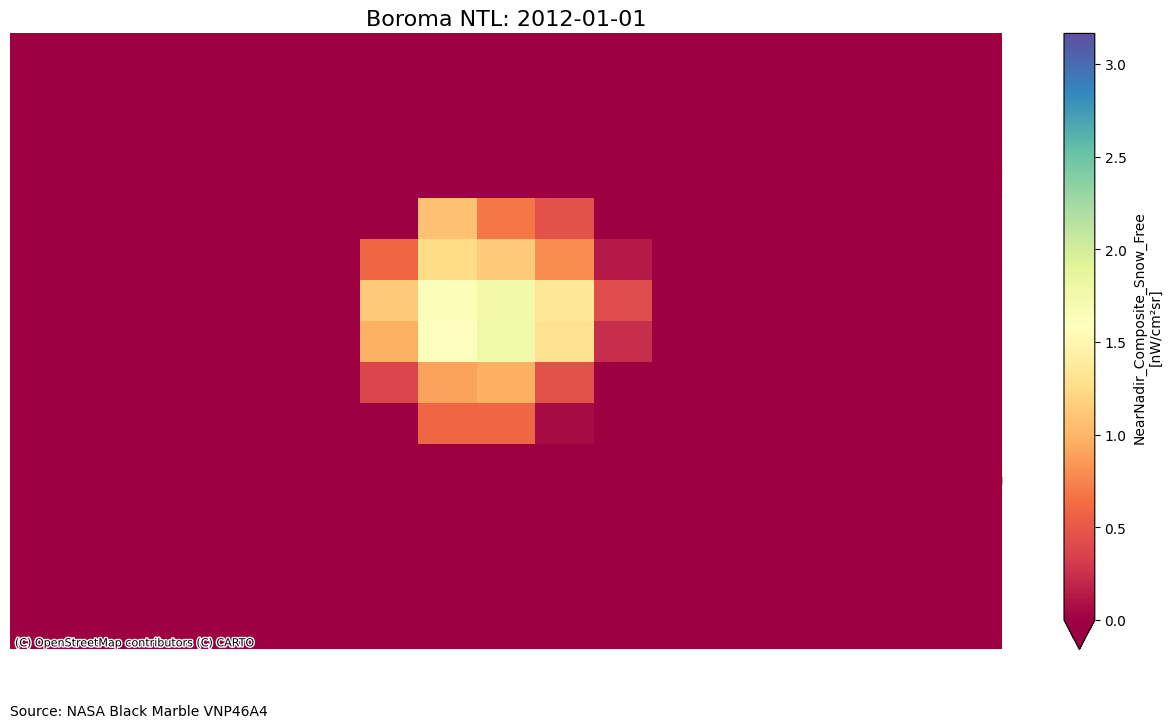

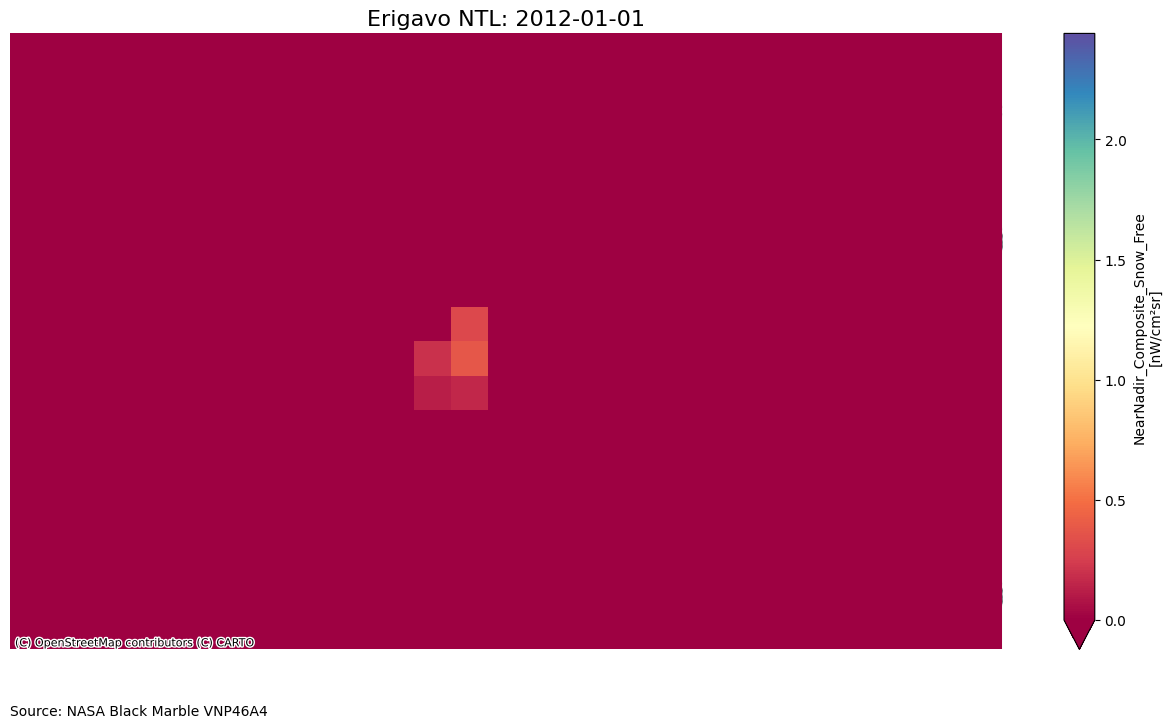

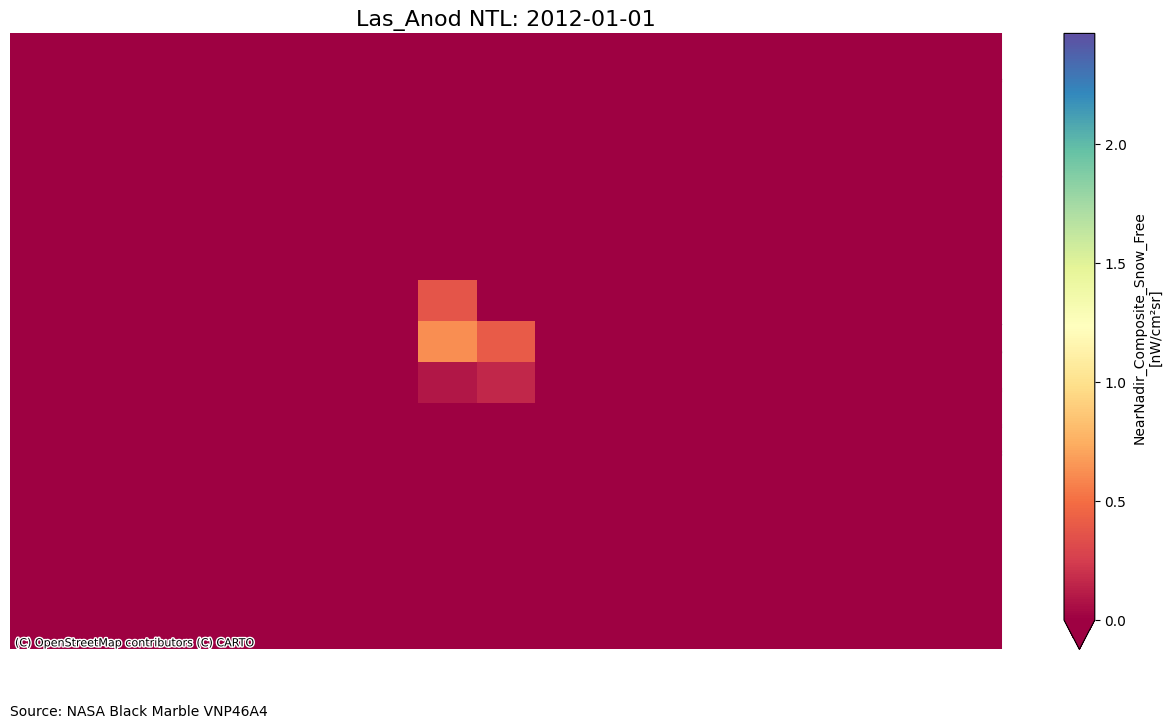

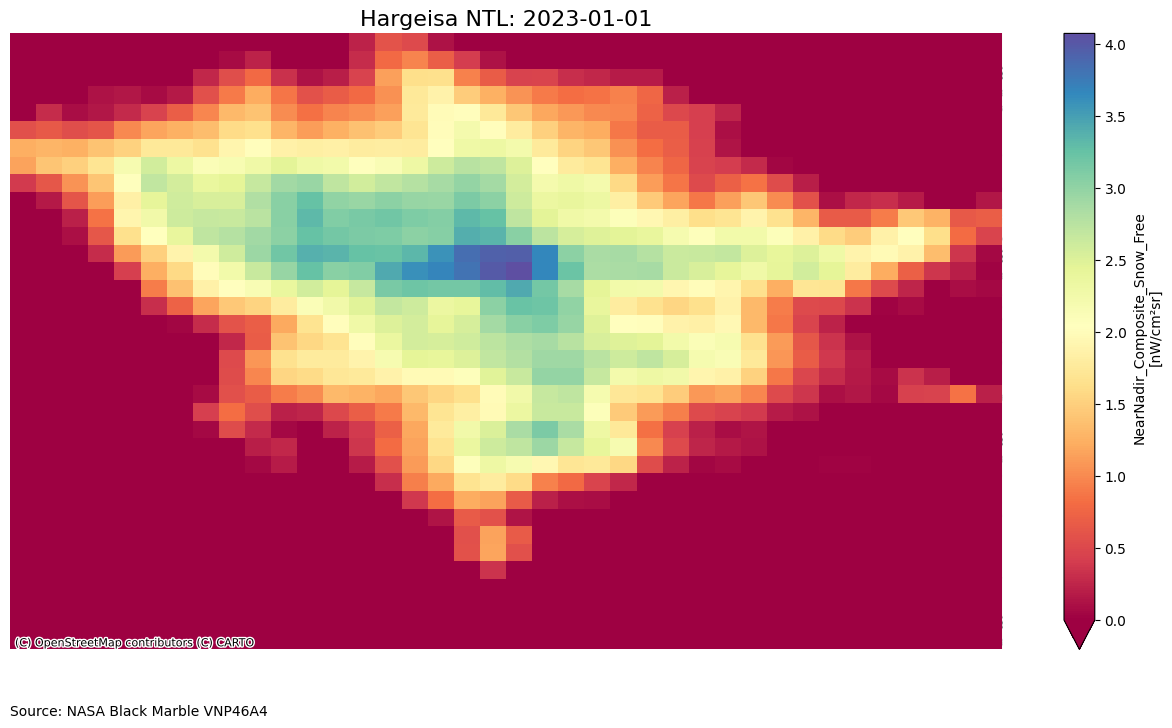

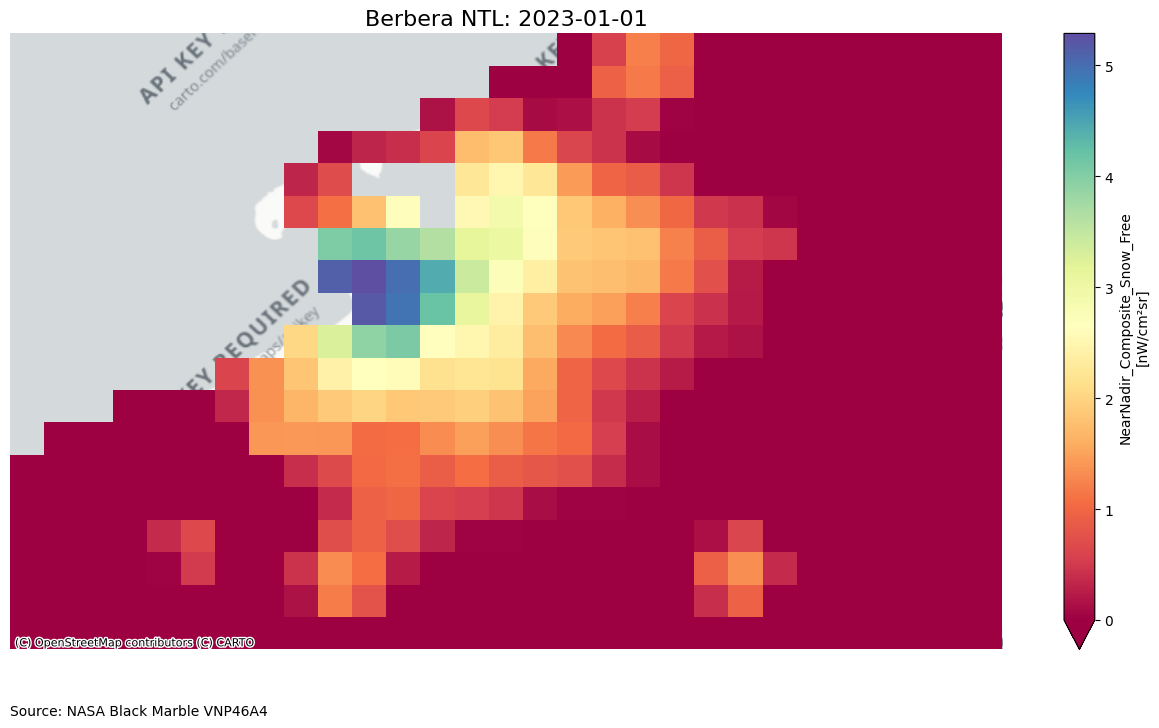

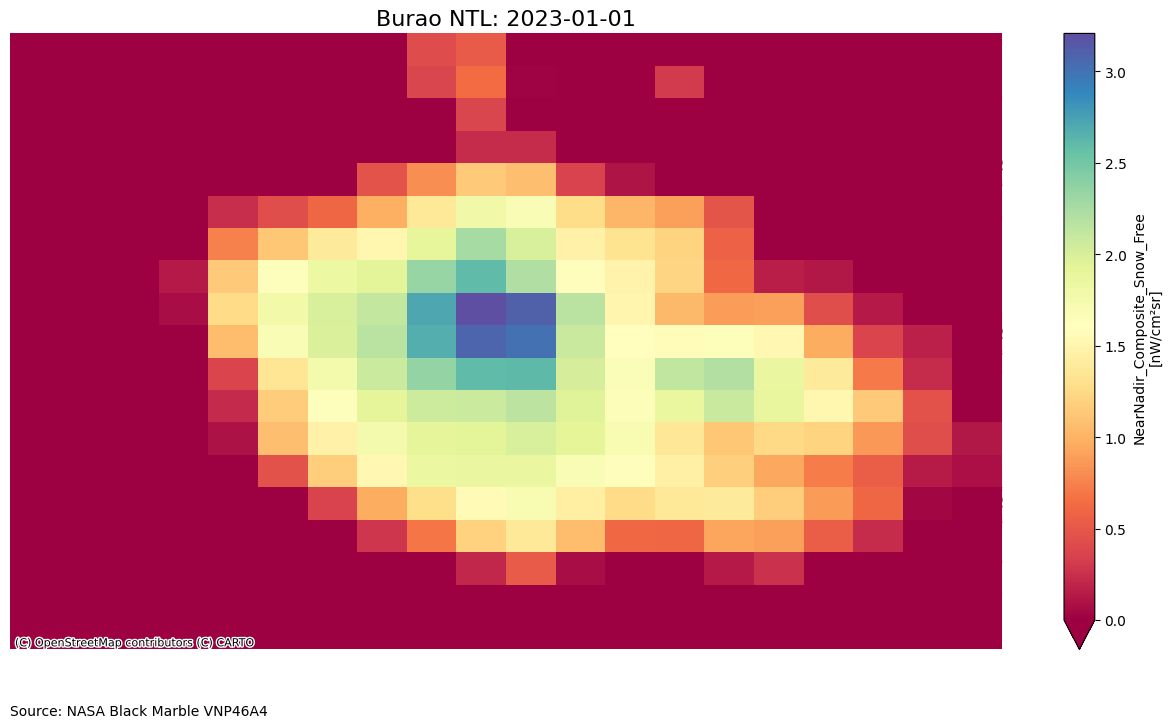

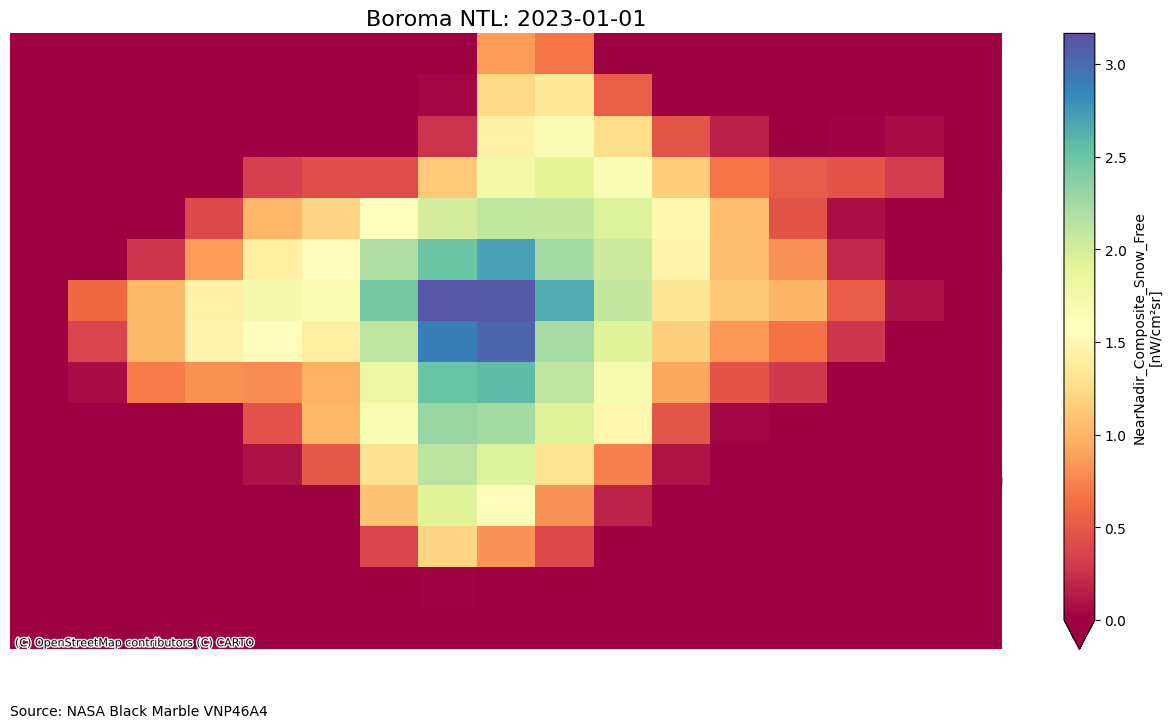

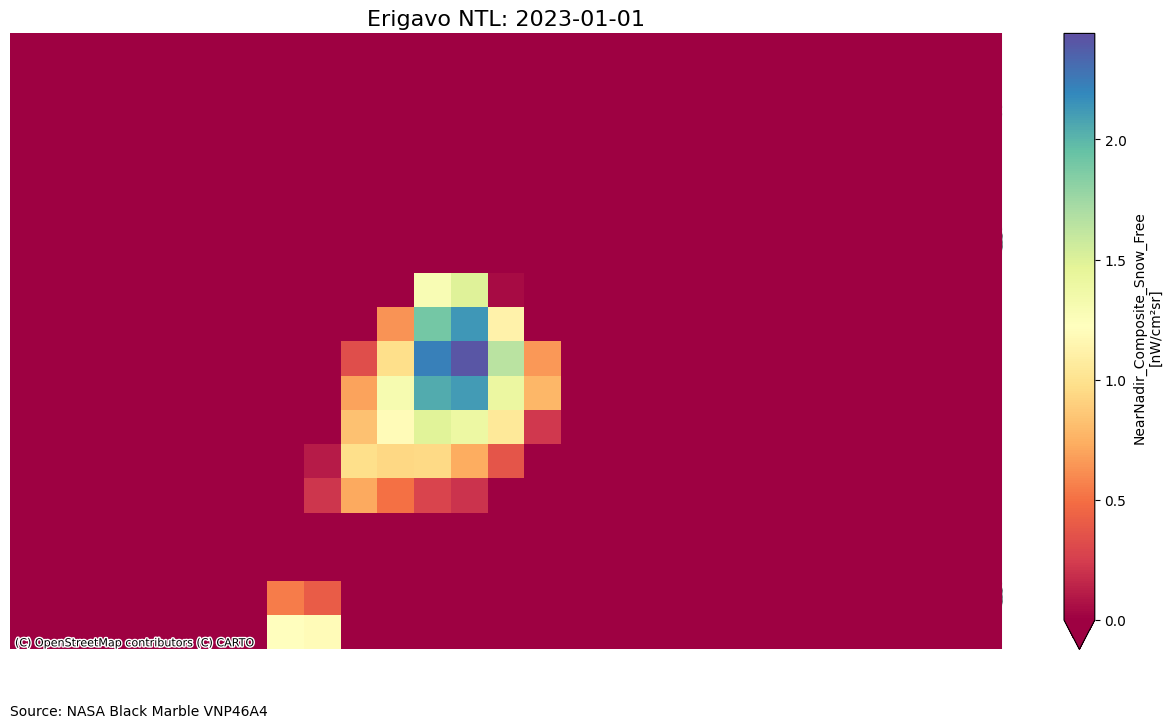

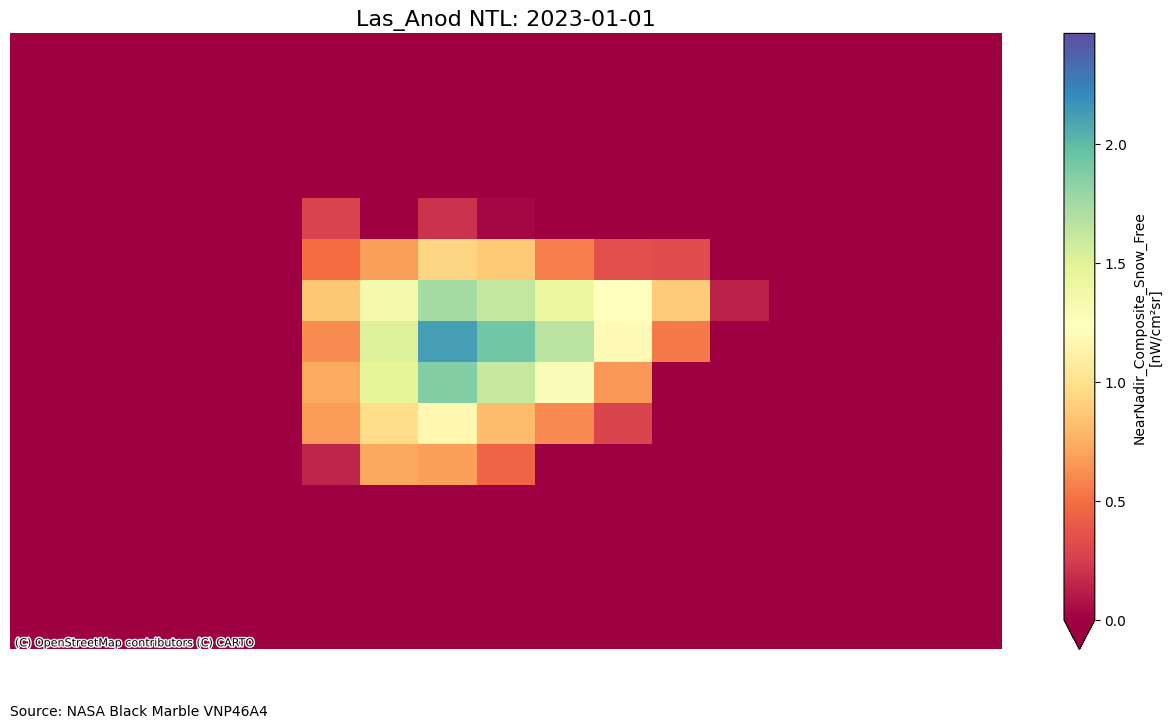

In [ ]:
for year in [2012, 2023]:
    for city in cities_ntl.keys():
        plot_NASA_NTL(cities_ntl_logged[city], cities[city], date = f"{year}-01-01", 
                    variable = "NearNadir_Composite_Snow_Free",
                    title_prefix = f"{city} NTL",
                    robust = False, vmin=0, vmax = cities_ntl_logged[city]["NearNadir_Composite_Snow_Free"].max())
        plt.savefig(f'../output/Graphics/{city}_{year}_Logged.png', dpi=300, bbox_inches='tight')
        plt.savefig(f'../Report/figures/{city}_{year}_Logged.png', dpi=300, bbox_inches='tight')

In [179]:
cities.keys()

dict_keys(['Hargeisa', 'Berbera', 'Burao', 'Boroma', 'Erigavo', 'Las_Anod'])

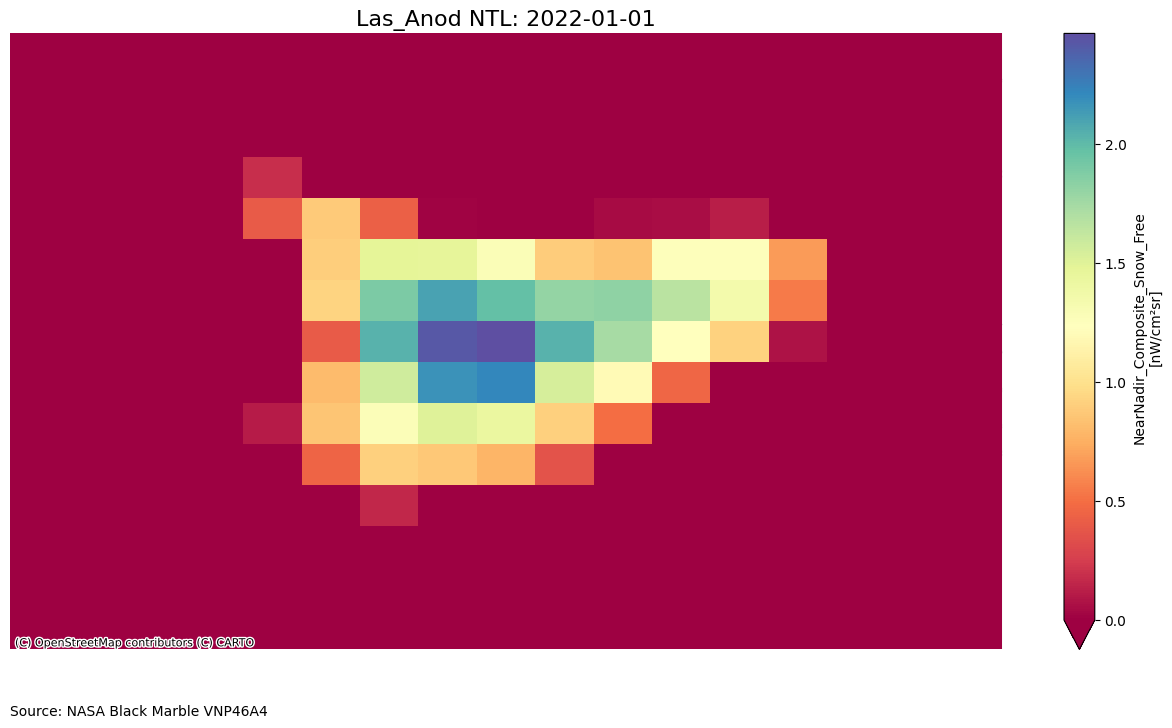

In [183]:
plot_NASA_NTL(cities_ntl_logged['Las_Anod'], cities['Las_Anod'], date = f"{2022}-01-01", 
                    variable = "NearNadir_Composite_Snow_Free",
                    title_prefix = f"{'Las_Anod'} NTL",
                    robust = False, vmin=0, vmax = cities_ntl_logged['Las_Anod']["NearNadir_Composite_Snow_Free"].max())
plt.savefig(f'../output/Graphics/Las_Anod_2022_Logged.png', dpi=300, bbox_inches='tight')
plt.savefig(f'../Report/figures/Las_Anod_2022_Logged.png', dpi=300, bbox_inches='tight')

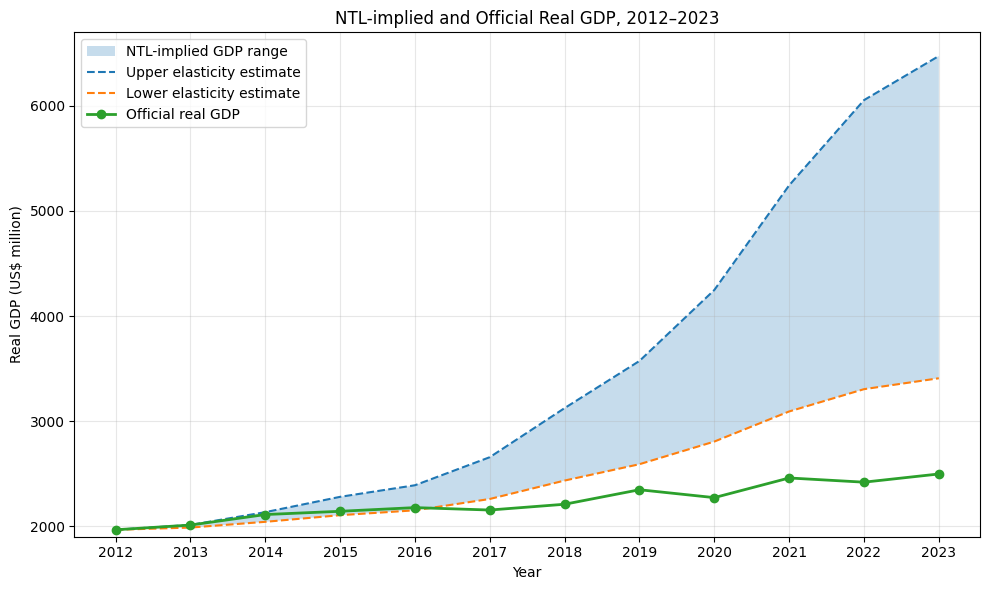

In [ ]:

years = range(2012, 2024)

fig, ax = plt.subplots(figsize=(10, 6))

# Shaded range between lower and upper NTL-implied GDP estimates
ax.fill_between(
    years,
    l_bound_gdp,
    u_bound_gdp,
    alpha=0.25,
    label="NTL-implied GDP range"
)

# Upper and lower NTL-implied GDP estimates
ax.plot(
    years,
    u_bound_gdp,
    linestyle="--",
    label="Upper elasticity estimate"
)

ax.plot(
    years,
    l_bound_gdp,
    linestyle="--",
    label="Lower elasticity estimate"
)

# Official GDP
ax.plot(
    years,
    official_gdp,
    marker="o",
    linewidth=2,
    label="Official real GDP"
)

# Formatting
ax.set_xlabel("Year")
ax.set_ylabel("Real GDP (US$ million)")
ax.set_title("NTL-implied and Official Real GDP, 2012–2023")

ax.set_xticks(list(years))
ax.set_ylim(bottom=1900)

ax.grid(True, alpha=0.3)
ax.legend()

fig.tight_layout()

# Save figure
fig.savefig(
    "../Report/figures/implied_gdp.png",
    dpi=300,
    bbox_inches="tight"
)

fig.savefig(
    "../output/Graphics/implied_gdp.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close(fig)

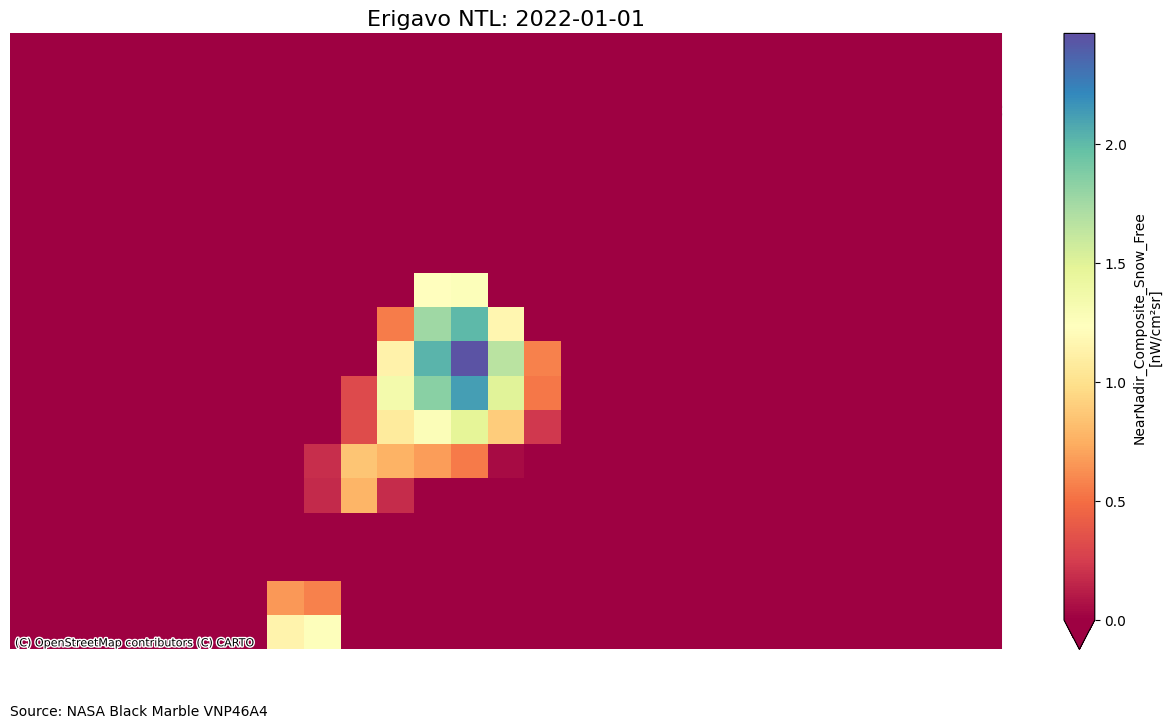

In [36]:
plot_NASA_NTL(cities_ntl_logged["Erigavo"], cities["Erigavo"], date = "2022-01-01", 
                    variable = "NearNadir_Composite_Snow_Free",
                    title_prefix = "Erigavo NTL",
                    robust = False, vmin=0, vmax = cities_ntl_logged[city]["NearNadir_Composite_Snow_Free"].max())
plt.savefig(f'../output/Graphics/{city}_{year}_Logged.png', dpi=300, bbox_inches='tight')

# GDP Growth Rate

In [ ]:
# Select NTL variable
ntl = SL_berbera["NearNadir_Composite_Snow_Free"]

# Calculate total NTL radiance for Berbera
total_radiance = ntl.sum(dim=["x", "y"])

# Calculate year-on-year change in log NTL
log_ntl = np.log(total_radiance)
log_ntl_growth = log_ntl.diff(dim="time")

# NTL-to-GDP elasticity assumptions
LOWER_ELASTICITY = 0.30
UPPER_ELASTICITY = 0.65

# Calculate implied GDP growth factors
l_bound = np.exp(LOWER_ELASTICITY * log_ntl_growth)
u_bound = np.exp(UPPER_ELASTICITY * log_ntl_growth)

# Official real GDP growth rates
official_gdp_growth = np.array([
    2.3, 5.0, 1.5, 1.6, -1.1,
    2.6, 6.2, -3.2, 8.2, -1.6, 3.2
])

# Convert percentage growth to growth factors
official_gdp_growth_factor = 1 + official_gdp_growth / 100

# Official GDP levels
official_gdp = np.array([
    1966, 2011, 2111, 2142, 2177, 2154,
    2209, 2347, 2272, 2459, 2419, 2497
])

# Starting GDP level
START_GDP = 1966

# Calculate implied GDP levels
l_bound_gdp = START_GDP * np.r_[
    1,
    np.cumprod(l_bound.to_numpy())
]

u_bound_gdp = START_GDP * np.r_[
    1,
   np.cumprod(u_bound.to_numpy())
]

In [171]:
u_bound_gdp[-1]

np.float64(6473.821891260781)

In [170]:
np.round((((u_bound_gdp[-1]-2497)/2497)*100),0)

np.float64(159.0)

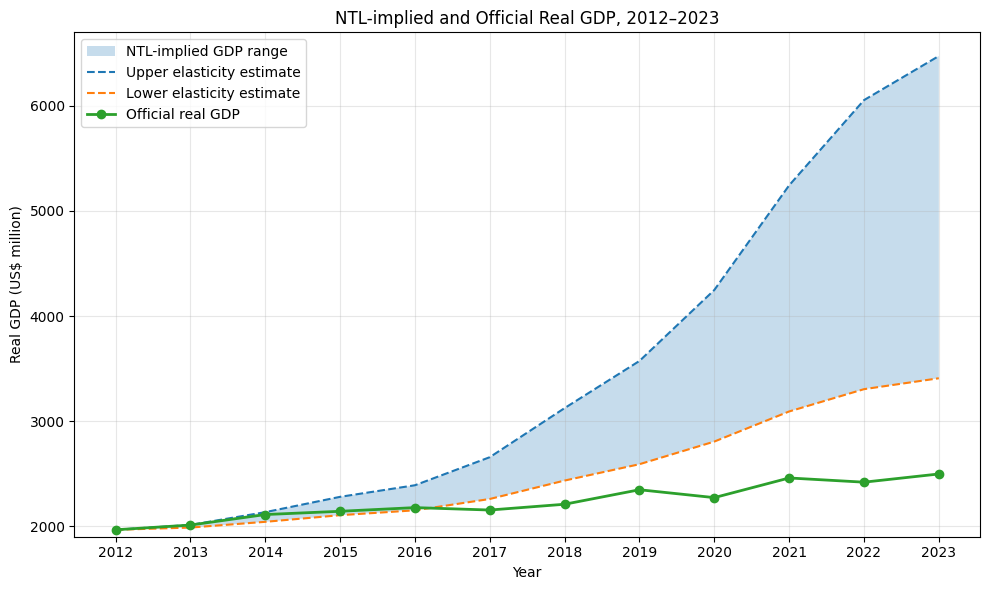

In [163]:

years = range(2012, 2024)

fig, ax = plt.subplots(figsize=(10, 6))

# Shaded range between lower and upper NTL-implied GDP estimates
ax.fill_between(
    years,
    l_bound_gdp,
    u_bound_gdp,
    alpha=0.25,
    label="NTL-implied GDP range"
)

# Upper and lower NTL-implied GDP estimates
ax.plot(
    years,
    u_bound_gdp,
    linestyle="--",
    label="Upper elasticity estimate"
)

ax.plot(
    years,
    l_bound_gdp,
    linestyle="--",
    label="Lower elasticity estimate"
)

# Official GDP
ax.plot(
    years,
    official_gdp,
    marker="o",
    linewidth=2,
    label="Official real GDP"
)

# Formatting
ax.set_xlabel("Year")
ax.set_ylabel("Real GDP (US$ million)")
ax.set_title("NTL-implied and Official Real GDP, 2012–2023")

ax.set_xticks(list(years))
ax.set_ylim(bottom=1900)

ax.grid(True, alpha=0.3)
ax.legend()

fig.tight_layout()

# Save figure
fig.savefig(
    "../Report/figures/implied_gdp.png",
    dpi=300,
    bbox_inches="tight"
)

fig.savefig(
    "../output/Graphics/implied_gdp.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close(fig)

## Additional Analysis 
### Regional Share of NTL Rad & Pixels

In [49]:
YEARS = np.arange(2012, 2024)
regions = {"Maroodi Jeex":[], "Togdheer":[], "Awdal":[], "Sool":[], "Sanaag":[], "Sahil":[]}
for region in regions:
    regions[region] = filter_dataset_by_bounding_box(mask_dataset_by_geometry(SL_berbera, somaliland_shp_berbera[somaliland_shp_berbera["admin1Name"]==region]), somaliland_shp_berbera[somaliland_shp_berbera["admin1Name"]== region])

region_rad_df = pd.DataFrame({
    region: yearly_radiance(region_data, YEARS)
    for region, region_data in regions.items()
})
region_rad_df["Total"] = region_rad_df.sum(axis=1)
region_rad_df.insert(0, "Year", YEARS)
region_rad_df = region_rad_df.set_index("Year")
shares_rad = region_rad_df[region_rad_df.columns[:-1]].div(region_rad_df["Total"], axis=0)

region_pixel_df = pd.DataFrame({
    region: yearly_nonzero_pixels(region_data, YEARS)
    for region, region_data in regions.items()
})
region_pixel_df["Total"] = region_pixel_df.sum(axis=1)
region_pixel_df.insert(0, "Year", YEARS)
region_pixel_df = region_pixel_df.set_index("Year")
shares_pixels = region_pixel_df[region_pixel_df.columns[:-1]].div(region_pixel_df["Total"], axis=0)

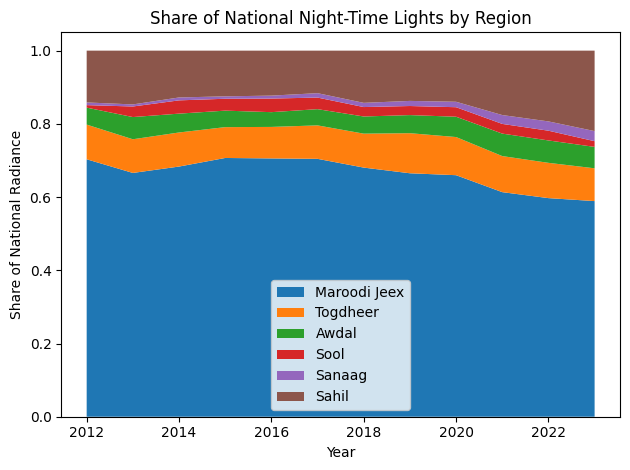

In [50]:
plt.figure()
plt.stackplot(
    shares_rad.index,
    shares_rad.T,
    labels=region_rad_df.columns
)

plt.title("Share of National Night-Time Lights by Region")
plt.ylabel("Share of National Radiance")
plt.xlabel("Year")
plt.legend(loc="best")
plt.tight_layout()
plt.show()


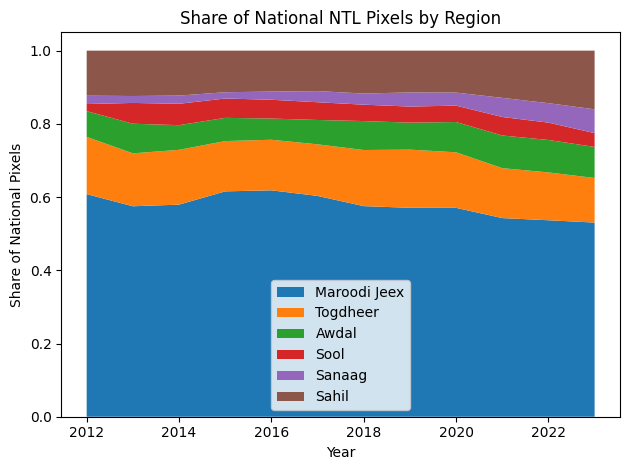

In [51]:
plt.figure()
plt.stackplot(
    shares_pixels.index,
    shares_pixels.T,
    labels=region_pixel_df.columns
)

plt.title("Share of National NTL Pixels by Region")
plt.ylabel("Share of National Pixels")
plt.xlabel("Year")
plt.legend(loc="best")
plt.tight_layout()
plt.show()

## Average Radiance per Region

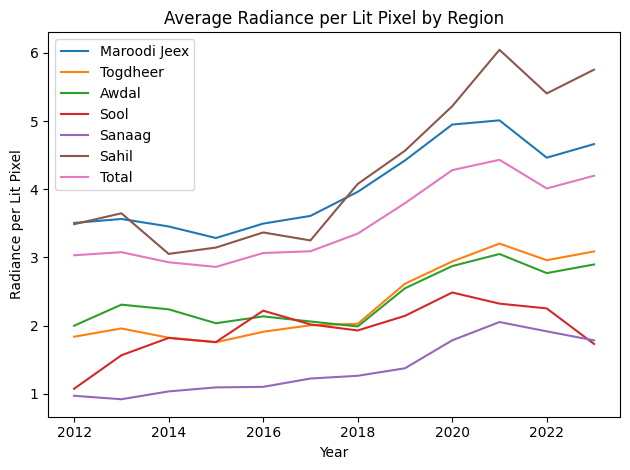

In [63]:
avg_rad_region = (
    region_rad_df[region_rad_df.columns] /
    region_pixel_df[region_pixel_df.columns]
)

plt.figure()
for region in region_rad_df.columns:
    plt.plot(avg_rad_region.index, avg_rad_region[region], label=region)

plt.title("Average Radiance per Lit Pixel by Region")
plt.xlabel("Year")
plt.ylabel("Radiance per Lit Pixel")
plt.legend()
plt.tight_layout()
plt.show()


In [65]:

df = (
    SL_berbera["NearNadir_Composite_Snow_Free"]
    .to_dataframe(name="radiance")
    .reset_index()
)

df["year"] = df["time"].dt.year
df.drop(columns="time", inplace=True)

df["pixel_id"] = (
    df.groupby(["x", "y"]).ngroup()
)

df["lit"] = df["radiance"] > 0


In [66]:
df.head()

,y,x,radiance,year,pixel_id,lit
0,11.510435,42.685539,NaN,2012,842,False
1,11.510435,42.689705,NaN,2012,1685,False
2,11.510435,42.693872,NaN,2012,2528,False
3,11.510435,42.698039,NaN,2012,3371,False
4,11.510435,42.702205,NaN,2012,4214,False


In [68]:
birth_year = (
    df[df["lit"]]
    .groupby("pixel_id")["year"]
    .min()
    .rename("birth_year")
)

df = df.merge(birth_year, on="pixel_id", how="left")
df["age"] = df["year"] - df["birth_year"]

df = df.sort_values(["pixel_id", "year"])

df["lit_next_year"] = (
    df.groupby("pixel_id")["lit"]
      .shift(-1)
)

df["survives_next_year"] = df["lit"] & df["lit_next_year"]

<Axes: title={'center': 'radiance'}, xlabel='survives_next_year'>

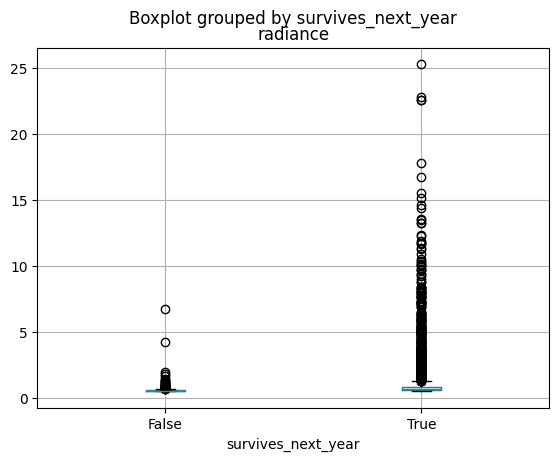

In [72]:
df[df["age"] == 0].boxplot(column="radiance", by="survives_next_year")

<Axes: xlabel='birth_year'>

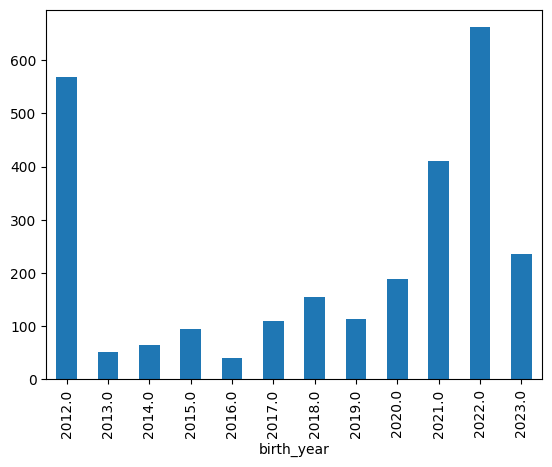

In [75]:
birth_counts = (
    df[df["birth_year"].notna()]
    .groupby("birth_year")["pixel_id"]
    .nunique()
)

birth_counts.plot(kind="bar")

<Axes: title={'center': 'radiance'}, xlabel='birth_year'>

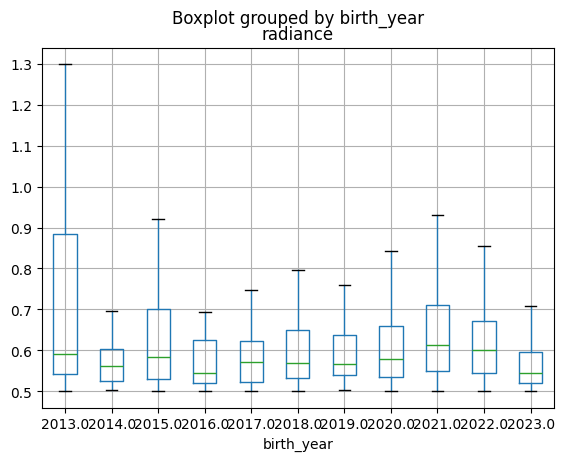

In [80]:
birth_df = df[(df["year"]!=2012) & (df["age"]==0)]

birth_df.boxplot(
    column="radiance",
    by="birth_year",
    showfliers=False
)

Text(0.5, 0, 'Years since birth')

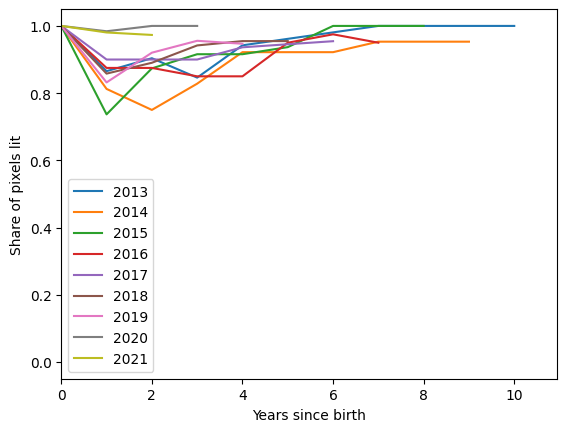

In [88]:
def survival_curve(birth_year):
    cohort = df[df["birth_year"] == birth_year]
    return (
        cohort.groupby("age")["lit"]
        .mean()
    )

for y in [2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021]:
    survival_curve(y).plot(label=str(y))

plt.xlim(0)
plt.legend()
plt.ylabel("Share of pixels lit")
plt.xlabel("Years since birth")